# Criando um classificador de Cachorros e Gatos

## Introdução
Este notebook tem como objetivo explorar imagens de cachorros e gatos e realizar classificações. 
A análise será dividida nas seguintes etapas:
1. Carregamento dos Dados
2. Análise Exploratória (EDA)
3. Treinamento do Modelo
4. Avaliação do Modelo

---

## 1. Carregamento de Bibliotecas e Configurações


In [2]:
!pip install pandas         --quiet
!pip install scikit-learn   --quiet
!pip install matplotlib     --quiet
!pip install numpy          --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install "vb-toolbox[ml] @ git+https://github.com/ViniLinharesBozzon/vb_toolbox.git" --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy                                    as np
import pandas                                   as pd
import matplotlib.pyplot                        as plt
import tensorflow
import platform
import pathlib
from PIL                import Image,ImageOps
from vb_toolbox.ml      import pre_analytics

In [5]:
# path com os caminhos necessários fixos.
c_pathImagens_str = 'dataset/PetImages'
c_pathCats_str    = c_pathImagens_str+'/Cat'
c_pathDogs_str    = c_pathImagens_str+'/Dog'

# exportando modelo para Databricks
if platform.node() == 'spark.host.local':
    # baixando a base de dados
    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

    print("Path to dataset files:", path)

---
## 2. Análise Exploratória(EDA)

 - As imagens tem proporção distintas em ambos os casos
 - Será necessário aplicar um tratamento em todas as imagens
 - Necessário replicar um forma de identificador para o treinamento.

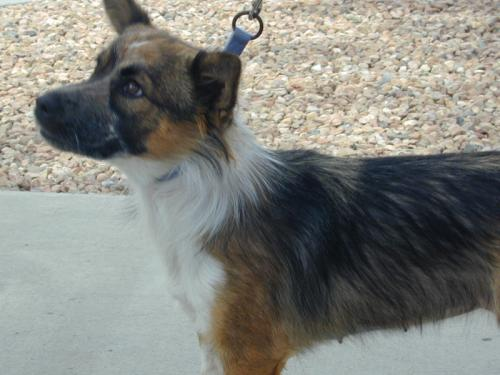

In [16]:
# Lendo uma imagem de cachorro
Image.open(c_pathDogs_str+'/3.jpg')

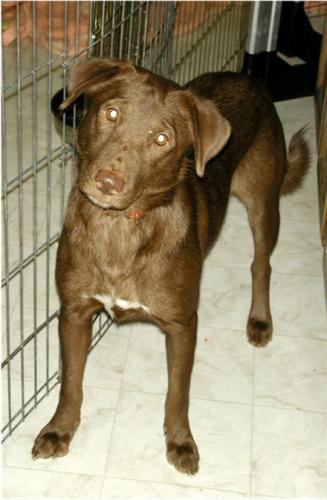

In [17]:
# Lendo uma imagem de cachorro
Image.open(c_pathDogs_str+'/1.jpg')

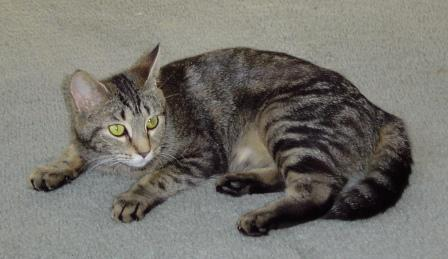

In [18]:
# verificando a base de gatos
Image.open(c_pathCats_str+'/16.jpg')

#### 2.2 Comparando imagem com e sem cor

In [19]:
v_fotoTeste_str = c_pathCats_str + '/16.jpg'

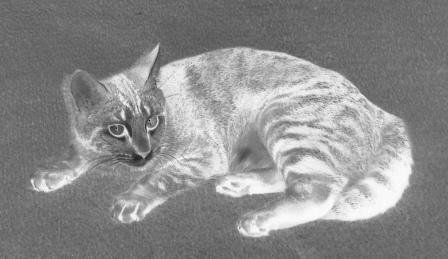

In [20]:
# Tentando aplicar a mesma regra da leitura de caractere
v_imagemTeste_pillow = Image.open(v_fotoTeste_str)
v_imagemTeste_pillow = v_imagemTeste_pillow.convert('L')
v_imagemTeste_pillow = ImageOps.invert(v_imagemTeste_pillow)
# v_imagemTeste_pillow = v_imagemTeste_pillow.resize((28,28))
v_imagemTeste_pillow

In [21]:
#### Provavelmente não fará sentido trocar a escala da imagem

--- 
## 3. Pre-Processamento
- Carregar a imagem dentro do vetor
- Usar o RGB Normalizado ( Rescaling )
- Redimensionar as imagens ( Reshape ) 


### 3.0 Procurando registros corrompidos

In [23]:
if platform.system() == 'Windows':
    !cd dataset/PetImages && dir
else:
    !cd dataset/PetImages && ls

 Volume in drive C is Windows
 Volume Serial Number is 54C5-37F6

 Directory of c:\Users\vinic\Documents\Notebooks\DogCatClassification\dataset\PetImages

04/15/2026  06:09 AM    <DIR>          .
04/15/2026  06:07 AM    <DIR>          ..
04/15/2026  06:09 AM    <DIR>          Cat
04/15/2026  06:10 AM    <DIR>          Dog
               0 File(s)              0 bytes
               4 Dir(s)  324,580,687,872 bytes free


In [24]:
# Removendo pastas de checkpoint
if platform.system() == 'Windows':
    !del "datasets/PetImages/.ipynb_checkpoints"
    !del "datasets/PetImages/Cat/.ipynb_checkpoints"
    !del "datasets/PetImages/Dogs/.ipynb_checkpoints"
else:
    !rm -rf "datasets/PetImages/.ipynb_checkpoints"
    !rm -rf "datasets/PetImages/Cat/.ipynb_checkpoints"
    !rm -rf "datasets/PetImages/Dogs/.ipynb_checkpoints"


The system cannot find the path specified.
The system cannot find the path specified.
The system cannot find the path specified.


In [ ]:
# verificando se existe apenas a pasta de Cat e Dog.
## O tensorflow vai ler as pastas como classe por isso não pode haver nada que não seja as classes.
if platform.system() == 'Windows':
    !cd dataset/PetImages && dir
else:
    !cd dataset/PetImages && ls

In [16]:
# Verificando se existe alguma imagem corrompida
import tensorflow as tf
import os
import glob

# Defina o caminho raiz
data_dir = 'datasets/PetImages' 

# Pega a lista de todos os arquivos .jpg (recursivamente)
# O glob vai achar datasets/PetImages/Cat/*.jpg e Dog/*.jpg
image_paths = glob.glob(os.path.join(data_dir, '*/*.jpg'))

print(f"Verificando {len(image_paths)} imagens com o próprio TensorFlow...")

deletados = 0

for image_path in image_paths:
    try:
        # 1. Lê os bytes do arquivo
        file_bytes = tf.io.read_file(image_path)
        
        # 2. Tenta decodificar usando a engine do TF
        # Isso força o TF a validar o cabeçalho e os dados
        img = tf.io.decode_image(file_bytes, channels=3, expand_animations=False)
        
    except Exception as e:
        # Se o TF reclamar (mesmo erro do treino), a gente apaga
        print(f"Arquivo podre encontrado: {image_path}")
        try:
            os.remove(image_path)
            deletados += 1
            print("--> DELETADO.")
        except:
            print("--> Erro ao tentar deletar.")

print("-" * 30)
print(f"Varredura Finalizada. Total deletado: {deletados}")

Verificando 0 imagens com o próprio TensorFlow...
------------------------------
Varredura Finalizada. Total deletado: 0


### 3.1 Separação de base de teste

In [18]:
c_pathImagens_pathlib    = pathlib.Path(c_pathImagens_str)
print(c_pathImagens_pathlib)

dataset\PetImages


In [19]:
# Constantes do modelo
c_batchSize_int         = 64 
c_imageHeight_int       = 180
c_imageWidth_int        = 180
c_validationSplit_floor = 0.2
c_seed_int              = 173

In [20]:
v_treinoDataset_tf  = tensorflow.keras.utils.image_dataset_from_directory(
    directory       = c_pathImagens_pathlib
,   validation_split= c_validationSplit_floor 
,   subset          = "training"
,   seed            = c_seed_int
,   image_size      = (c_imageHeight_int,c_imageWidth_int)
,   batch_size      = c_batchSize_int
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.


In [21]:
v_testeDataset_tf  = tensorflow.keras.utils.image_dataset_from_directory(
    directory       = c_pathImagens_pathlib
,   validation_split= c_validationSplit_floor 
,   subset          = "validation"
,   seed            = c_seed_int
,   image_size      = (c_imageHeight_int,c_imageWidth_int)
,   batch_size      = c_batchSize_int
)

Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [26]:
# Verificando se as classes estão corretas:
print(v_treinoDataset_tf.class_names)
c_numeroClasses_int = len(v_treinoDataset_tf.class_names)

['Cat', 'Dog']


--- 
## 4. Treinamento do Modelo
- Usar o RGB Normalizado ( Rescaling )

A fazer:
Colocar Data Augmentation ( virar  as imagens ) 

In [27]:
v_modeloCNN_tf = tensorflow.keras.models.Sequential([
     tensorflow.keras.layers.Rescaling(1./255 , input_shape=(c_imageHeight_int,c_imageWidth_int,3)) # Normalizando o RGB e usando 3 camadas devido ao RGB
,    tensorflow.keras.layers.Conv2D(16,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Conv2D(32,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Conv2D(64,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Flatten()                                                              # Reorganiza os vetores das camadas para decisão
,    tensorflow.keras.layers.Dense(128, activation="relu")                                          # Decisão baseada nos fatiamentos das camadas.
,    tensorflow.keras.layers.Dropout(0.5)                                                           # Desligando metade dos neurônios durante o treinamento
,    tensorflow.keras.layers.Dense(c_numeroClasses_int, activation="softmax")                       # Decisão deve ser baseada pela quantidade de classes existentes: cães / gatos 
# e retornar em 0 - 100% de chance.
])

c:\Users\vinic\Documents\Notebooks\DogCatClassification\DogCatClassification-venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
v_modeloCNN_tf.compile(
     optimizer='adam'
,    loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
,    metrics=['accuracy']
)

In [29]:
epochs=7
history = v_modeloCNN_tf.fit(
  v_treinoDataset_tf
, validation_data=v_testeDataset_tf
, epochs=epochs
)

Epoch 1/7


c:\Users\vinic\Documents\Notebooks\DogCatClassification\DogCatClassification-venv\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


KeyboardInterrupt: 

---
# 5. Avaliando o Modelo

In [31]:
def f_set_avaliationImage(v_path_str):
    # 1- Lendo uma imagem
    img = tf.keras.utils.load_img(
        v_path_str, target_size=(c_imageHeight_int, c_imageWidth_int)
    ) 
    
    # 2. Converte a imagem para um array de números (matriz)
    img_array = tf.keras.utils.img_to_array(img)
    
    # 3. Cria um lote (batch) de uma imagem só
    # O modelo espera receber um lote, tipo (1, 180, 180, 3)
    img_array = tf.expand_dims(img_array, 0)
    
    # 4. Faz a previsão
    previsoes = v_modeloCNN_tf.predict(img_array)
    
    # 5. Traduz o resultado
    # Como usamos Softmax, 'previsoes' é uma lista de probabilidades: [ChanceGato, ChanceCachorro]
    score = previsoes[0]
    
    # Pega a classe com maior valor
    classe_vencedora_index = np.argmax(score)
    
    # Recupera os nomes das classes (que vimos lá no começo: ['Cat', 'Dog'])
    # Se você não salvou em uma variável, pode escrever na mão: nomes_classes = ['Gato', 'Cachorro']
    nomes_classes = v_treinoDataset_tf.class_names
    
    print(f"------------------------------------------------")
    print(f"Imagem: {v_path_str}")
    print(f"Resultado: {nomes_classes[classe_vencedora_index]}")
    print(f"Confiança: {100 * np.max(score):.2f}%")
    print(f"Detalhe: {score}") # Mostra os números brutos pra você ver

In [32]:
# v_imagePath_str = c_pathDogs_str+"/20.jpg"
v_imagePath_str = c_pathDogs_str+"/5445.jpg"
# v_imagePath_str = c_pathCats_str+"/40.jpg"

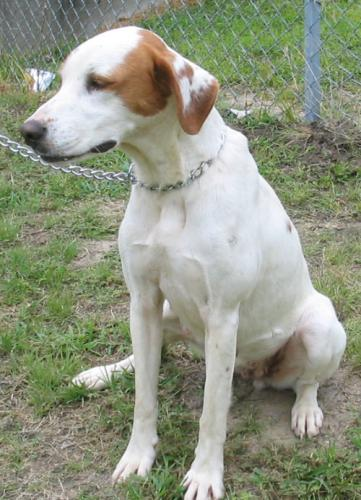

In [33]:
Image.open(v_imagePath_str)

In [34]:
f_set_avaliationImage(v_imagePath_str)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
------------------------------------------------
Imagem: dataset/PetImages/Dog/5445.jpg
Resultado: Cat
Confiança: 56.25%
Detalhe: [0.5624698  0.43753025]


### 5.2 - Validação Cruzada

In [37]:
test_loss, test_acc = v_modeloCNN_tf.evaluate(x_test, y_test, verbose=2)
print("\nAcurácia no teste:", test_acc)

NameError: name 'x_test' is not defined

---
## 6. Exportando o modelo